## Part A - Scikit-learn Implementation

In [817]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import time
from sklearn.model_selection import FixedThresholdClassifier


df = pd.read_csv("garments_worker_productivity.csv")

print(df.head())


       date   quarter  department       day  team  targeted_productivity  \
0  1/1/2015  Quarter1      sweing  Thursday     8                   0.80   
1  1/1/2015  Quarter1  finishing   Thursday     1                   0.75   
2  1/1/2015  Quarter1      sweing  Thursday    11                   0.80   
3  1/1/2015  Quarter1      sweing  Thursday    12                   0.80   
4  1/1/2015  Quarter1      sweing  Thursday     6                   0.80   

     smv     wip  over_time  incentive  idle_time  idle_men  \
0  26.16  1108.0       7080         98        0.0         0   
1   3.94     NaN        960          0        0.0         0   
2  11.41   968.0       3660         50        0.0         0   
3  11.41   968.0       3660         50        0.0         0   
4  25.90  1170.0       1920         50        0.0         0   

   no_of_style_change  no_of_workers  actual_productivity  
0                   0           59.0             0.940725  
1                   0            8.0        

In [818]:

print(df.shape)


(1197, 15)


In [819]:

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   str    
 1   quarter                1197 non-null   str    
 2   department             1197 non-null   str    
 3   day                    1197 non-null   str    
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: float64(6), 

In [820]:

missing_pct = (
    df.isnull().sum() / len(df) * 100
)

print(missing_pct,df.isnull().sum())

date                      0.000000
quarter                   0.000000
department                0.000000
day                       0.000000
team                      0.000000
targeted_productivity     0.000000
smv                       0.000000
wip                      42.272348
over_time                 0.000000
incentive                 0.000000
idle_time                 0.000000
idle_men                  0.000000
no_of_style_change        0.000000
no_of_workers             0.000000
actual_productivity       0.000000
dtype: float64 date                       0
quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
dtype: int64


In [821]:

df.duplicated().sum()

np.int64(0)

In [822]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
team,1197.0,6.426901,3.463963,1.000000,3.000000,6.000000,9.000000,12.000000
targeted_productivity,1197.0,0.729632,0.097891,0.070000,0.700000,0.750000,0.800000,0.800000
smv,1197.0,15.062172,10.943219,2.900000,3.940000,15.260000,24.260000,54.560000
wip,691.0,1190.465991,1837.455001,7.000000,774.500000,1039.000000,1252.500000,23122.000000
over_time,1197.0,4567.460317,3348.823563,0.000000,1440.000000,3960.000000,6960.000000,25920.000000
incentive,1197.0,38.210526,160.182643,0.000000,0.000000,0.000000,50.000000,3600.000000
idle_time,1197.0,0.730159,12.709757,0.000000,0.000000,0.000000,0.000000,300.000000
idle_men,1197.0,0.369256,3.268987,0.000000,0.000000,0.000000,0.000000,45.000000
no_of_style_change,1197.0,0.150376,0.427848,0.000000,0.000000,0.000000,0.000000,2.000000
no_of_workers,1197.0,34.609858,22.197687,2.000000,9.000000,34.000000,57.000000,89.000000


In [823]:
for col in df.columns:
    print(col, ":", df[col].nunique())

date : 59
quarter : 5
department : 3
day : 6
team : 12
targeted_productivity : 9
smv : 70
wip : 548
over_time : 143
incentive : 48
idle_time : 12
idle_men : 10
no_of_style_change : 3
no_of_workers : 61
actual_productivity : 879


In [824]:
df['department'] = df['department'].str.strip()

In [825]:
numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

print("Numeric columns:", numeric_columns)

categorical_columns = df.select_dtypes(
    include=["object", "str"]
).columns

print("Categorical columns:", categorical_columns)

Numeric columns: Index(['team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive',
       'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers',
       'actual_productivity'],
      dtype='str')
Categorical columns: Index(['date', 'quarter', 'department', 'day'], dtype='str')


In [826]:
for col in categorical_columns:
    print("\n", col)
    print(df[col].value_counts(dropna=False))


 date
date
1/31/2015    24
3/11/2015    24
1/11/2015    23
1/12/2015    23
1/24/2015    23
3/10/2015    23
1/5/2015     22
1/7/2015     22
1/8/2015     22
1/10/2015    22
1/13/2015    22
1/22/2015    22
3/3/2015     22
3/8/2015     22
3/9/2015     22
1/3/2015     21
1/4/2015     21
1/6/2015     21
1/14/2015    21
1/17/2015    21
1/25/2015    21
1/27/2015    21
1/28/2015    21
2/18/2015    21
2/25/2015    21
2/26/2015    21
2/28/2015    21
3/4/2015     21
1/29/2015    20
2/17/2015    20
2/19/2015    20
2/22/2015    20
3/1/2015     20
3/2/2015     20
1/1/2015     19
1/15/2015    19
1/18/2015    19
1/19/2015    19
1/21/2015    19
1/26/2015    19
2/1/2015     19
2/2/2015     19
2/3/2015     19
2/4/2015     19
2/7/2015     19
2/8/2015     19
2/10/2015    19
2/11/2015    19
2/12/2015    19
2/15/2015    19
2/23/2015    19
2/24/2015    19
3/5/2015     19
3/7/2015     19
2/5/2015     18
2/9/2015     18
2/16/2015    18
2/14/2015    17
1/20/2015    15
Name: count, dtype: int64

 quarter
quarter


In [827]:
print(df[numeric_columns].describe().T)
print("\n", df["over_time"].describe())

                        count         mean          std       min  \
team                   1197.0     6.426901     3.463963  1.000000   
targeted_productivity  1197.0     0.729632     0.097891  0.070000   
smv                    1197.0    15.062172    10.943219  2.900000   
wip                     691.0  1190.465991  1837.455001  7.000000   
over_time              1197.0  4567.460317  3348.823563  0.000000   
incentive              1197.0    38.210526   160.182643  0.000000   
idle_time              1197.0     0.730159    12.709757  0.000000   
idle_men               1197.0     0.369256     3.268987  0.000000   
no_of_style_change     1197.0     0.150376     0.427848  0.000000   
no_of_workers          1197.0    34.609858    22.197687  2.000000   
actual_productivity    1197.0     0.735091     0.174488  0.233705   

                               25%          50%          75%           max  
team                      3.000000     6.000000     9.000000     12.000000  
targeted_producti

In [828]:
print(df["actual_productivity"].describe())
print("skewness = " , df["actual_productivity"].skew())

count    1197.000000
mean        0.735091
std         0.174488
min         0.233705
25%         0.650307
50%         0.773333
75%         0.850253
max         1.120437
Name: actual_productivity, dtype: float64
skewness =  -0.8074917745097576


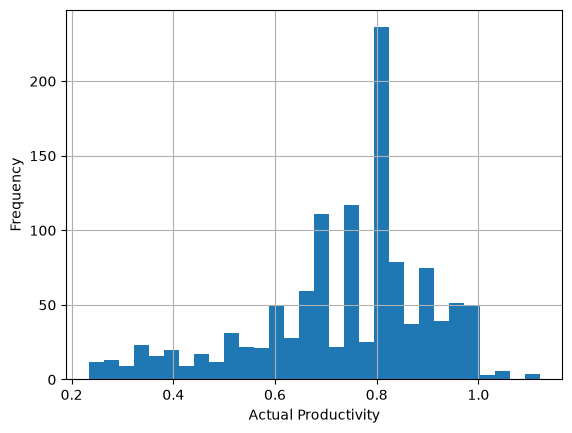

In [829]:
(df["actual_productivity"].hist(bins=30))
plt.xlabel("Actual Productivity")
plt.ylabel("Frequency")
plt.show()


In [830]:
df.select_dtypes(include="number").corr()["actual_productivity"].sort_values()

no_of_style_change      -0.207366
idle_men                -0.181734
team                    -0.148753
smv                     -0.122089
idle_time               -0.080851
no_of_workers           -0.057991
over_time               -0.054206
incentive                0.076538
wip                      0.131147
targeted_productivity    0.421594
actual_productivity      1.000000
Name: actual_productivity, dtype: float64

In [831]:
df[[
    "targeted_productivity",
    "actual_productivity"
]].describe()

,targeted_productivity,actual_productivity
count,1197.000000,1197.000000
mean,0.729632,0.735091
std,0.097891,0.174488
min,0.070000,0.233705
25%,0.700000,0.650307
50%,0.750000,0.773333
75%,0.800000,0.850253
max,0.800000,1.120437


In [832]:
df["MeetsTarget"] = (
    df["actual_productivity"]
    >= df["targeted_productivity"]
).astype(int)

In [833]:
df["MeetsTarget"].value_counts()

MeetsTarget
1    875
0    322
Name: count, dtype: int64

In [834]:
df["MeetsTarget"].value_counts(normalize=True)

MeetsTarget
1    0.730994
0    0.269006
Name: proportion, dtype: float64

### Train-Test split

In [835]:
X = df.drop(
    columns=["actual_productivity", "MeetsTarget"]
)

In [836]:
X_reg = df.drop(
    columns=["actual_productivity", "MeetsTarget"]
)

y_reg = df["actual_productivity"]

In [837]:
X_clf = df.drop(
    columns=["MeetsTarget", "actual_productivity"]
)

y_clf = df["MeetsTarget"]

In [838]:
productivity_bin = pd.qcut(
    y_reg,
    q=5,
    labels=False,
    duplicates="drop"
)

comb_stratify = (
    productivity_bin.astype(str)
    + "_"
    + y_clf.astype(str)
)


train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.20,
    random_state=42,
    stratify=comb_stratify
)

In [839]:
comb_stratify.value_counts().sort_index()

0_0    178
0_1     62
1_0    119
1_1    120
2_0     25
2_1    214
3_1    239
4_1    240
Name: count, dtype: int64

In [840]:
print("Total:", len(df))
print("Train:", len(train_idx))
print("Test :", len(test_idx))

print("Train %:", len(train_idx) / len(df))
print("Test % :", len(test_idx) / len(df))

Total: 1197
Train: 957
Test : 240
Train %: 0.7994987468671679
Test % : 0.20050125313283207


In [841]:
print("Overall:")
print(comb_stratify.value_counts(normalize=True).sort_index())

print("\nTrain:")
print(
    comb_stratify.loc[train_idx]
    .value_counts(normalize=True)
    .sort_index()
)


print("\nTest:")
print(
    comb_stratify.loc[test_idx]
    .value_counts(normalize=True)
    .sort_index()
)

Overall:
0_0    0.148705
0_1    0.051796
1_0    0.099415
1_1    0.100251
2_0    0.020886
2_1    0.178780
3_1    0.199666
4_1    0.200501
Name: proportion, dtype: float64

Train:
0_0    0.148380
0_1    0.052247
1_0    0.099269
1_1    0.100313
2_0    0.020899
2_1    0.178683
3_1    0.199582
4_1    0.200627
Name: proportion, dtype: float64

Test:
0_0    0.150000
0_1    0.050000
1_0    0.100000
1_1    0.100000
2_0    0.020833
2_1    0.179167
3_1    0.200000
4_1    0.200000
Name: proportion, dtype: float64


In [842]:
print("Overall:")
print(
    y_clf.value_counts(normalize=True)
    .sort_index()
)

print("\nTrain:")
print(
    y_clf.loc[train_idx]
    .value_counts(normalize=True)
    .sort_index()
)

print("\nTest:")
print(
    y_clf.loc[test_idx]
    .value_counts(normalize=True)
    .sort_index()
)

Overall:
MeetsTarget
0    0.269006
1    0.730994
Name: proportion, dtype: float64

Train:
MeetsTarget
0    0.268548
1    0.731452
Name: proportion, dtype: float64

Test:
MeetsTarget
0    0.270833
1    0.729167
Name: proportion, dtype: float64


In [843]:
print("Overall:")
print(y_reg.describe())

print("\nTrain:")
print(
    y_reg.loc[train_idx].describe()
)

print("\nTest:")
print(
    y_reg.loc[test_idx].describe()
)

Overall:
count    1197.000000
mean        0.735091
std         0.174488
min         0.233705
25%         0.650307
50%         0.773333
75%         0.850253
max         1.120437
Name: actual_productivity, dtype: float64

Train:
count    957.000000
mean       0.734735
std        0.176300
min        0.233705
25%        0.650148
50%        0.763375
75%        0.850362
max        1.120437
Name: actual_productivity, dtype: float64

Test:
count    240.000000
mean       0.736512
std        0.167418
min        0.238042
25%        0.668121
50%        0.789729
75%        0.846886
max        1.000446
Name: actual_productivity, dtype: float64


In [844]:
overlap = set(train_idx).intersection(set(test_idx))

print("Overlapping rows:", len(overlap))

Overlapping rows: 0


In [845]:
print(
    "All rows accounted for:",
    len(train_idx) + len(test_idx) == len(df)
)

All rows accounted for: True


In [846]:
X_train = X.loc[train_idx]
X_test  = X.loc[test_idx]

In [847]:
X_reg_train = X_reg.loc[train_idx]
X_reg_test = X_reg.loc[test_idx]

y_reg_train = y_reg.loc[train_idx]
y_reg_test = y_reg.loc[test_idx]

In [848]:
X_clf_train = X_clf.loc[train_idx]
X_clf_test = X_clf.loc[test_idx]

y_clf_train = y_clf.loc[train_idx]
y_clf_test = y_clf.loc[test_idx]

### Preprocessing 

In [849]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print(numeric_features)

['team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers']


In [850]:
categorical_features = X_train.select_dtypes(
    include=["object", "category","str"]
).columns.tolist()

print(categorical_features)

['date', 'quarter', 'department', 'day']


In [851]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [852]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [853]:


preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [854]:
preprocessor.fit(X_reg_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [855]:
X_reg_train_processed = preprocessor.transform(X_reg_train)
X_reg_test_processed = preprocessor.transform(X_reg_test)

X_clf_train_processed = preprocessor.transform(X_clf_train)
X_clf_test_processed = preprocessor.transform(X_clf_test)

### Training 


In [856]:
regression_model = LinearRegression()

In [857]:
classification_model = LogisticRegression(max_iter=1000)

In [858]:
# Regression
start_time = time.perf_counter()

regression_model.fit(
    X_reg_train_processed,
    y_reg_train
)

reg_train_time = time.perf_counter() - start_time

In [859]:

# Classification
start_time = time.perf_counter()

classification_model.fit(
    X_clf_train_processed,
    y_clf_train
)

clf_train_time = time.perf_counter() - start_time

## Prediction 

### Regression prediction 


In [860]:
start_time = time.perf_counter()

y_reg_pred = regression_model.predict(
    X_reg_test_processed
)

reg_pred_time = time.perf_counter() - start_time

In [861]:
print("Regression predictions :", y_reg_pred.shape)
print("Regression actual      :", y_reg_test.shape)

print("Actual regression values:")
print(y_reg_test.head())

print("\nPredicted regression values:")
print(y_reg_pred[:5])

Regression predictions : (240,)
Regression actual      : (240,)
Actual regression values:
253    0.600370
161    0.800344
635    0.496550
900    0.371563
861    0.609583
Name: actual_productivity, dtype: float64

Predicted regression values:
[0.68591919 0.79029848 0.8006998  0.73606426 0.71724116]


### Classification prediction

In [862]:
start_time = time.perf_counter()

y_clf_pred = classification_model.predict(
    X_clf_test_processed
)

clf_pred_time = time.perf_counter() - start_time

In [863]:
print("Classification predictions :", y_clf_pred.shape)
print("Classification actual      :", y_clf_test.shape)

print("Actual classification values:")
print(y_clf_test.head())

print("\nPredicted classification values:")
print(y_clf_pred[:5])

Classification predictions : (240,)
Classification actual      : (240,)
Actual classification values:
253    1
161    1
635    0
900    0
861    0
Name: MeetsTarget, dtype: int64

Predicted classification values:
[1 1 1 1 0]


##  Evaluation measures


In [864]:
# Regression Metrics


reg_mae = mean_absolute_error(y_reg_test, y_reg_pred)

reg_rmse = np.sqrt(
    mean_squared_error(y_reg_test, y_reg_pred)
)

reg_r2 = r2_score(y_reg_test, y_reg_pred)

print("Regression Results")

print("MAE :", reg_mae)
print("RMSE:", reg_rmse)
print("R²  :", reg_r2)

Regression Results
MAE : 0.10359824949179712
RMSE: 0.1437510484471011
R²  : 0.2596625451754304


In [865]:
clf_accuracy = accuracy_score(y_clf_test, y_clf_pred)

clf_precision = precision_score(
    y_clf_test,
    y_clf_pred
)

clf_recall = recall_score(
    y_clf_test,
    y_clf_pred
)

clf_f1 = f1_score(
    y_clf_test,
    y_clf_pred
)

print("Classification Results")

print("Accuracy :", clf_accuracy)
print("Precision:", clf_precision)
print("Recall   :", clf_recall)
print("F1-score :", clf_f1)

Classification Results
Accuracy : 0.7416666666666667
Precision: 0.7652582159624414
Recall   : 0.9314285714285714
F1-score : 0.8402061855670103


In [866]:
results_part_a = pd.DataFrame([
    {
        "Task": "Regression",
        "Model": "Linear Regression",
        "MAE": reg_mae,
        "RMSE": reg_rmse,
        "R2": reg_r2,
        "Accuracy": None,
        "Precision": None,
        "Recall": None,
        "F1": None,
        "Train Time (s)": reg_train_time,
        "Prediction Time (s)": reg_pred_time
    },
    {
        "Task": "Classification",
        "Model": "Logistic Regression",
        "MAE": None,
        "RMSE": None,
        "R2": None,
        "Accuracy": clf_accuracy,
        "Precision": clf_precision,
        "Recall": clf_recall,
        "F1": clf_f1,
        "Train Time (s)": clf_train_time,
        "Prediction Time (s)": clf_pred_time
    }
])

results_part_a.T

,0,1
Task,Regression,Classification
Model,Linear Regression,Logistic Regression
MAE,0.103598,NaN
RMSE,0.143751,NaN
R2,0.259663,NaN
Accuracy,NaN,0.741667
Precision,NaN,0.765258
Recall,NaN,0.931429
F1,NaN,0.840206
Train Time (s),0.006348,0.012889


In [867]:
regression_results = pd.DataFrame({
    "Model": ["Scikit-learn Linear Regression"],
    "MAE": [reg_mae],
    "RMSE": [reg_rmse],
    "R2": [reg_r2],
    "Training Time (s)": [reg_train_time],
    "Prediction Time (s)": [reg_pred_time],
})

regression_results

,Model,MAE,RMSE,R2,Training Time (s),Prediction Time (s)
0,Scikit-learn Linear Regression,0.103598,0.143751,0.259663,0.006348,0.000429


In [868]:
classification_results = pd.DataFrame({
    "Model": ["Scikit-learn Logistic Regression"],
    "Accuracy": [clf_accuracy],
    "Precision": [clf_precision],
    "Recall": [clf_recall],
    "F1-Score": [clf_f1],
    "Training Time (s)": [clf_train_time],
    "Prediction Time (s)": [clf_pred_time],
})

classification_results

,Model,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Scikit-learn Logistic Regression,0.741667,0.765258,0.931429,0.840206,0.012889,0.0008


### Part B - From-Scratch Implementation

In [869]:
X_train = X.loc[train_idx].copy()
X_test = X.loc[test_idx].copy()

y_reg_train = y_reg.loc[train_idx].copy()
y_reg_test = y_reg.loc[test_idx].copy()

y_clf_train = y_clf.loc[train_idx].copy()
y_clf_test = y_clf.loc[test_idx].copy()

In [870]:
categorical_cols = X_train.select_dtypes(
    include=["object","str"]
).columns.tolist()

print("Categorical columns:")
print(categorical_cols)



numerical_cols = X_train.select_dtypes(
    exclude=["object","str"]
).columns.tolist()


print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
['date', 'quarter', 'department', 'day']

Numerical columns:
['team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers']


### Imputing 


In [871]:
numeric_medians = X_train[numerical_cols].median()

X_train[numerical_cols] = X_train[numerical_cols].fillna(
    numeric_medians
)

X_test[numerical_cols] = X_test[numerical_cols].fillna(
    numeric_medians
)

categorical_modes = X_train[categorical_cols].mode().iloc[0]

X_train[categorical_cols] = X_train[categorical_cols].fillna(
    categorical_modes
)

X_test[categorical_cols] = X_test[categorical_cols].fillna(
    categorical_modes
)

### One-Hot Encoding

In [872]:
X_train_encoded = pd.get_dummies(
    X_train,
    columns=categorical_cols,
    dtype=float
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    dtype=float
)

X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

In [873]:
print("Training shape:", X_train_encoded.shape)
print("Test shape    :", X_test_encoded.shape)

print(
    "Same columns:",
    X_train_encoded.columns.equals(
        X_test_encoded.columns
    )
)

print(
    X_train_encoded.select_dtypes(
        include=["object", "category","str"]
    ).columns.tolist()
)

Training shape: (957, 82)
Test shape    : (240, 82)
Same columns: True
[]


### Feature Scaling

In [874]:
X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

In [875]:
numeric_means = X_train[numerical_cols].mean()
numeric_stds = X_train[numerical_cols].std()

X_train_scaled[numerical_cols] = (
    X_train_scaled[numerical_cols] - numeric_means
) / numeric_stds

X_test_scaled[numerical_cols] = (
    X_test_scaled[numerical_cols] - numeric_means
) / numeric_stds

### Linear Regression 


In [876]:
# converting the scaled DataFrames to numpy arrays for regression

X_train_lr = X_train_scaled.to_numpy()
X_test_lr = X_test_scaled.to_numpy()

y_train_lr = y_reg_train.to_numpy()
y_test_lr = y_reg_test.to_numpy()

In [877]:
# Adding one at index 0 for the intercept term in linear regression

X_train_lr = np.column_stack([
    np.ones(X_train_lr.shape[0]),
    X_train_lr
])

X_test_lr = np.column_stack([
    np.ones(X_test_lr.shape[0]),
    X_test_lr
])

In [878]:
print("Training matrix shape:", X_train_lr.shape)
print("Test matrix shape    :", X_test_lr.shape)

Training matrix shape: (957, 83)
Test matrix shape    : (240, 83)


In [879]:
start_time = time.perf_counter()

XTX = X_train_lr.T @ X_train_lr
XTy = X_train_lr.T @ y_train_lr

beta = np.linalg.solve(
    XTX,
    XTy
)

linear_scratch_train_time = (
    time.perf_counter() - start_time
)
print("Number of coefficients:", len(beta))
print("\nFirst few coefficients:")
print(beta[:5])

Number of coefficients: 83

First few coefficients:
[-2.46666688 -0.02563893  0.07064169 -0.07346502  0.01421503]


### Prediction 


In [880]:
start_time = time.perf_counter()

y_reg_pred_scratch = X_test_lr @ beta

linear_scratch_prediction_time = (
    time.perf_counter() - start_time
)

print("Actual values shape    :", y_test_lr.shape)
print("Predicted values shape :", y_reg_pred_scratch.shape)

Actual values shape    : (240,)
Predicted values shape : (240,)


In [881]:
print("Actual values:")
print(y_test_lr[:5])

print("\nPredicted values:")
print(y_reg_pred_scratch[:5])

Actual values:
[0.60036969 0.80034377 0.49654971 0.3715625  0.60958333]

Predicted values:
[0.68591986 0.79029904 0.80069733 0.73606193 0.7172391 ]


### Evaluation Matrices 


In [882]:
# scratch MAE
mae_scratch = np.mean(
    np.abs(y_test_lr - y_reg_pred_scratch)
)

# scratch RMSE
rmse_scratch = np.sqrt(
    np.mean(
        (y_test_lr - y_reg_pred_scratch) ** 2
    )
)

# scratch R²
ss_res = np.sum(
    (y_test_lr - y_reg_pred_scratch) ** 2
)

ss_tot = np.sum(
    (y_test_lr - np.mean(y_test_lr)) ** 2
)

r2_scratch = 1 - (ss_res / ss_tot)

print("scratch Regression Results")

print("MAE :", mae_scratch)
print("RMSE:", rmse_scratch)
print("R²  :", r2_scratch)


print("\nTraining time   :", linear_scratch_train_time)
print("Prediction time :", linear_scratch_prediction_time)

scratch Regression Results
MAE : 0.10359832768206949
RMSE: 0.14375111558008108
R²  : 0.2596618536873102

Training time   : 0.0017951999980141409
Prediction time : 0.0003705000017362181


In [883]:
regression_comparison = pd.DataFrame({
    "Implementation": [
        "Scikit-learn",
        "From Scratch"
    ],
    "MAE": [
        reg_mae,
        mae_scratch
    ],
    "RMSE": [
        reg_rmse,
        rmse_scratch
    ],
    "R2": [
        reg_r2,
        r2_scratch
    ],
    "Training Time (s)": [
        reg_train_time,
        linear_scratch_train_time
    ],
    "Prediction Time (s)": [
        reg_pred_time,
        linear_scratch_prediction_time
    ]
})

regression_comparison.round(6)

,Implementation,MAE,RMSE,R2,Training Time (s),Prediction Time (s)
0,Scikit-learn,0.103598,0.143751,0.259663,0.006348,0.000429
1,From Scratch,0.103598,0.143751,0.259662,0.001795,0.000371


### Logistic Regression


In [884]:
X_train_log = X_train_scaled.to_numpy()
X_test_log = X_test_scaled.to_numpy()

y_train_log = y_clf_train.to_numpy()
y_test_log = y_clf_test.to_numpy()

In [885]:
# Adding one at index 0 for the intercept term in logistic regression

X_train_log = np.column_stack([
    np.ones(X_train_log.shape[0]),
    X_train_log
])

X_test_log = np.column_stack([
    np.ones(X_test_log.shape[0]),
    X_test_log
])

print("Training matrix shape:", X_train_log.shape)
print("Test matrix shape    :", X_test_log.shape)

Training matrix shape: (957, 83)
Test matrix shape    : (240, 83)


Initialize the parameters

In [886]:
beta_log = np.zeros(X_train_log.shape[1])

print("Number of parameters:", len(beta_log))
print("Initial parameters:", beta_log)

Number of parameters: 83
Initial parameters: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


implimentation of sigmoid


In [887]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

convert prob to classes

In [888]:
def predict_class(probabilities, threshold=0.5):
    return (probabilities >= threshold).astype(int)

predict probability

In [889]:
def predict_probability(X, beta):
    z = X @ beta
    return sigmoid(z)

prob_train = predict_probability(
    X_train_log,
    beta_log
)
print("Predicted probabilities (first 5):")
print(prob_train[:5])


Predicted probabilities (first 5):
[0.5 0.5 0.5 0.5 0.5]


* log loss

In [890]:
epsilon = 1e-15

prob_train_safe = np.clip(
    prob_train,
    epsilon,
    1 - epsilon
)

log_loss = -np.mean(
    y_train_log * np.log(prob_train_safe)
    +
    (1 - y_train_log) * np.log(1 - prob_train_safe)
)

print("Initial log loss:", log_loss)

Initial log loss: 0.6931471805599452


calculate gradient 

In [891]:
gradient = (
    X_train_log.T @ (prob_train - y_train_log)
) / len(y_train_log)

print("Gradient shape:", gradient.shape)

Gradient shape: (83,)


### Updating para ( gradient descent)

In [892]:
learning_rate = 0.01
beta_log = beta_log - learning_rate * gradient

In [893]:
def train_logistic_regression(
    X_train,
    y_train,
    learning_rate=0.01,
    n_iterations=1000
):
    # 1. Initialize parameters
    beta = np.zeros(X_train.shape[1])

    # Store loss during training
    loss_history = []

    # 2. Training loop
    for iteration in range(n_iterations):

        # Linear score
        z = X_train @ beta

        # Predicted probability
        probability = sigmoid(z)

        # Prevent log(0)
        probability_safe = np.clip(
            probability,
            1e-15,
            1 - 1e-15
        )

        # Log loss
        loss = -np.mean(
            y_train * np.log(probability_safe)
            +
            (1 - y_train) * np.log(1 - probability_safe)
        )

        # Gradient
        gradient = (
            X_train.T @ (probability - y_train)
        ) / len(y_train)

        # Update parameters
        beta = beta - learning_rate * gradient

        # Store loss
        loss_history.append(loss)

    return beta

Train the logistic model 

In [894]:
start_time = time.perf_counter()

beta_log = train_logistic_regression(
    X_train_log,
    y_train_log,
    learning_rate=0.01,
    n_iterations=1000
)

logistic_scratch_train_time = (
    time.perf_counter() - start_time
)

In [895]:
print(beta_log)

[ 5.28477547e-01 -1.20738509e-01  6.07506869e-03 -5.13728988e-02
  1.20688812e-01  7.86186224e-02  1.13045106e-01 -3.32294309e-02
 -3.02962462e-01 -6.30561030e-02  2.90572905e-01 -9.56382534e-03
  1.43128958e-02  1.01589910e-02  4.43159796e-03  1.04694499e-02
  1.75899495e-02  1.21351530e-02  1.64190359e-02  7.21140935e-03
  5.24615805e-03  9.41640321e-03  1.43720069e-02 -1.95750647e-02
  8.97424295e-03  2.93118851e-02  3.43044228e-02  3.59201657e-02
  1.54266604e-02  2.75824289e-02  1.67323128e-02  5.93740339e-02
  2.94161743e-04  4.91970759e-02  1.90862364e-02  1.50781783e-02
  1.49491142e-02  1.73158151e-02  1.57521393e-02  1.81494668e-02
 -1.82577463e-02  3.98476510e-03 -2.78876304e-02 -1.41970335e-02
  1.94547143e-02 -4.26984239e-04 -3.10741006e-02 -7.31062665e-03
 -2.30255773e-02  8.75041433e-03 -2.18620368e-03  7.53170401e-03
 -1.68008530e-02 -5.73297474e-03  7.07696658e-04  6.38447487e-03
  1.83359011e-02 -9.66955462e-04 -9.34780315e-03  3.53952041e-03
  1.57159399e-03  4.56630

In [896]:
start_time = time.perf_counter()

y_clf_prob_scratch = predict_probability(
    X_test_log,
    beta_log
)

logistic_scratch_prediction_time = (
    time.perf_counter() - start_time
)

Apply the thresold 

In [897]:
y_clf_pred_scratch = predict_class(
    y_clf_prob_scratch,
    threshold=0.5
)

In [898]:
print("Actual:")
print(y_test_log[:20].astype(int))

print("\nPredicted:")
print(y_clf_pred_scratch[:20])

Actual:
[1 1 0 0 0 1 0 1 1 0 1 1 1 1 1 1 1 0 0 0]

Predicted:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [899]:
comparison = pd.DataFrame({
    "Actual": y_test_log,
    "Predicted_Probability": y_clf_prob_scratch,
    "Predicted_Class": y_clf_pred_scratch
})

print(comparison.head(10))

   Actual  Predicted_Probability  Predicted_Class
0       1               0.850500                1
1       1               0.801237                1
2       0               0.816922                1
3       0               0.584893                1
4       0               0.513346                1
5       1               0.843991                1
6       0               0.835500                1
7       1               0.675712                1
8       1               0.664391                1
9       0               0.577415                1


Classification Metrics

In [900]:
tp = np.sum(
    (y_test_log == 1) &
    (y_clf_pred_scratch == 1)
)

tn = np.sum(
    (y_test_log == 0) &
    (y_clf_pred_scratch == 0)
)

fp = np.sum(
    (y_test_log == 0) &
    (y_clf_pred_scratch == 1)
)

fn = np.sum(
    (y_test_log == 1) &
    (y_clf_pred_scratch == 0)
)

In [901]:
print("True Positives :", tp)
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)

print("Total:", tp + tn + fp + fn)
print("Test size:", len(y_test_log))

True Positives : 175
True Negatives : 1
False Positives: 64
False Negatives: 0
Total: 240
Test size: 240


### Accuracy 


In [902]:
accuracy_manual = (
    (tp + tn) /
    (tp + tn + fp + fn)
)

print("Accuracy:", accuracy_manual)

Accuracy: 0.7333333333333333


### Precision 

In [903]:
precision_manual = tp / (tp + fp)

print("Precision:", precision_manual)

Precision: 0.7322175732217573


Recall

In [904]:
recall_manual = tp / (tp + fn)

print("Recall:", recall_manual)

Recall: 1.0


F1 Score

In [905]:
f1_manual = (
    2 * precision_manual * recall_manual
    / (precision_manual + recall_manual)
)

print("F1 Score:", f1_manual)

F1 Score: 0.8454106280193237


In [906]:
print("Accuracy :", accuracy_manual)
print("Precision:", precision_manual)
print("Recall   :", recall_manual)
print("F1 Score :", f1_manual)


print("\nTraining time   :", logistic_scratch_train_time)
print("Prediction time :", logistic_scratch_prediction_time)

Accuracy : 0.7333333333333333
Precision: 0.7322175732217573
Recall   : 1.0
F1 Score : 0.8454106280193237

Training time   : 0.2188953999975638
Prediction time : 0.000485699998534983


### comparision table

In [907]:
classification_comparison = pd.DataFrame({
    "Implementation": [
        "Scikit-learn",
        "From Scratch"
    ],
    "Accuracy": [
        clf_accuracy,
        accuracy_manual
    ],
    "Precision": [
        clf_precision,
        precision_manual    
    ],
    "Recall": [
        clf_recall,
        recall_manual   
    ],
    "F1-Score": [
        clf_f1,
        f1_manual
    ],
    "Training Time (s)": [
        clf_train_time,
        logistic_scratch_train_time
    ],
    "Prediction Time (s)": [
        clf_pred_time,
        logistic_scratch_prediction_time
    ]
})

classification_comparison.round(6)

,Implementation,Accuracy,Precision,Recall,F1-Score,Training Time (s),Prediction Time (s)
0,Scikit-learn,0.741667,0.765258,0.931429,0.840206,0.012889,0.000800
1,From Scratch,0.733333,0.732218,1.000000,0.845411,0.218895,0.000486


### Part C - Comparison and Optimization

Linear Regression

The NumPy implementation reproduced the Scikit-learn results almost exactly, with identical MAE and RMSE and an R² difference of only 0.000001.


Logistic Regression

The manual implementation achieved comparable predictive performance. It obtained higher recall and slightly higher F1, while Scikit-learn achieved higher accuracy and precision. The major difference was training time: the gradient-descent implementation required approximately 18.6× more training time.

Therefore, the primary optimization target is the manual Logistic Regression training procedure, particularly the number of unnecessary gradient-descent iterations and convergence behavior.

### Optimization Step 1: Learning Rate and Convergence Tuning

In [908]:
def train_logistic_regression(
    X_train,
    y_train,
    learning_rate=0.01,
    n_iterations=1000,
    tolerance=1e-7,
    print_every=100
):
    # 1. Initialize parameters
    beta = np.zeros(X_train.shape[1])

    # Store loss
    loss_history = []

    # Track convergence
    converged = False

    for iteration in range(n_iterations):

        # 2. Linear score
        z = X_train @ beta

        # 3. Predicted probability
        probability = sigmoid(z)

        # Prevent log(0)
        probability_safe = np.clip(
            probability,
            1e-15,
            1 - 1e-15
        )

        # 4. Log loss
        loss = -np.mean(
            y_train * np.log(probability_safe)
            +
            (1 - y_train) * np.log(1 - probability_safe)
        )

        loss_history.append(loss)

        # 5. Gradient
        gradient = (
            X_train.T @ (probability - y_train)
        ) / len(y_train)

        # 6. Update parameters
        beta = beta - learning_rate * gradient

        # 7. Calculate loss change
        if iteration == 0:
            loss_change = np.nan
        else:
            loss_change = abs(
                loss_history[-2] - loss_history[-1]
            )

        # 8. Print progress
        if (
            iteration == 0
            or (iteration + 1) % print_every == 0
        ):
            print(
                f"Iteration: {iteration + 1:4d} | "
                f"Loss: {loss:.8f} | "
                f"Loss Change: {loss_change:.10f}"
            )

        # 9. Check convergence
        if iteration > 0 and loss_change < tolerance:

            converged = True

            print(
                f"\nConverged at iteration {iteration + 1}"
            )

            print(
                f"Loss change ({loss_change:.10f}) "
                f"< tolerance ({tolerance})"
            )

            break

    # 10. If maximum iterations reached
    if not converged:
        print(
            f"\nNot converged within {n_iterations} iterations."
        )

        print(
            f"Final loss change: {loss_change:.10f}"
        )

        print(
            f"Required tolerance: {tolerance}"
        )

    return beta, loss_history, iteration + 1, converged

In [909]:
start_time = time.perf_counter()

beta_log, loss_history, iterations_used, converged = (
    train_logistic_regression(
        X_train_log,
        y_train_log,
        learning_rate=0.01,
        n_iterations=1000,
        tolerance=1e-7,
        print_every=100
    )
)

logistic_optimized_train_time = (
    time.perf_counter() - start_time
)
print("\nTraining Summary")

print("Learning rate      :", 0.01)
print("Maximum iterations :", 1000)
print("Iterations used    :", iterations_used)
print("Initial loss       :", loss_history[0])
print("Final loss         :", loss_history[-1])
print("Final loss change  :", abs(
    loss_history[-2] - loss_history[-1]
))
print("Tolerance          :", 1e-7)
print("Converged          :", converged)
print("Training time (s)  :", logistic_optimized_train_time)

Iteration:    1 | Loss: 0.69314718 | Loss Change: nan
Iteration:  100 | Loss: 0.60406209 | Loss Change: 0.0005385053
Iteration:  200 | Loss: 0.56815834 | Loss Change: 0.0002336381
Iteration:  300 | Loss: 0.55155480 | Loss Change: 0.0001166660
Iteration:  400 | Loss: 0.54276987 | Loss Change: 0.0000660934
Iteration:  500 | Loss: 0.53750964 | Loss Change: 0.0000421412
Iteration:  600 | Loss: 0.53397807 | Loss Change: 0.0000298956
Iteration:  700 | Loss: 0.53135924 | Loss Change: 0.0000231757
Iteration:  800 | Loss: 0.52925756 | Loss Change: 0.0000192211
Iteration:  900 | Loss: 0.52747034 | Loss Change: 0.0000167238
Iteration: 1000 | Loss: 0.52588835 | Loss Change: 0.0000150327

Not converged within 1000 iterations.
Final loss change: 0.0000150327
Required tolerance: 1e-07

Training Summary
Learning rate      : 0.01
Maximum iterations : 1000
Iterations used    : 1000
Initial loss       : 0.6931471805599452
Final loss         : 0.5258883450058673
Final loss change  : 1.5032680127147202e-05

### Try for 5000 iteration

In [910]:
start_time = time.perf_counter()

beta_log, loss_history, iterations_used, converged = (
    train_logistic_regression(
        X_train_log,
        y_train_log,
        learning_rate=0.01,
        n_iterations=5000,
        tolerance=1e-7,
        print_every=500
    )
)

logistic_optimized_train_time = (
    time.perf_counter() - start_time
)

print("\nTraining Summary")

print("Learning rate      :", 0.01)
print("Maximum iterations :", 5000)
print("Iterations used    :", iterations_used)
print("Initial loss       :", loss_history[0])
print("Final loss         :", loss_history[-1])
print(
    "Final loss change  :",
    abs(loss_history[-2] - loss_history[-1])
)
print("Tolerance          :", 1e-7)
print("Converged          :", converged)
print("Training time (s)  :", logistic_optimized_train_time)

Iteration:    1 | Loss: 0.69314718 | Loss Change: nan
Iteration:  500 | Loss: 0.53750964 | Loss Change: 0.0000421412
Iteration: 1000 | Loss: 0.52588835 | Loss Change: 0.0000150327
Iteration: 1500 | Loss: 0.51957259 | Loss Change: 0.0000109294
Iteration: 2000 | Loss: 0.51465448 | Loss Change: 0.0000088971
Iteration: 2500 | Loss: 0.51057801 | Loss Change: 0.0000074817
Iteration: 3000 | Loss: 0.50711906 | Loss Change: 0.0000064003
Iteration: 3500 | Loss: 0.50414181 | Loss Change: 0.0000055414
Iteration: 4000 | Loss: 0.50155175 | Loss Change: 0.0000048433
Iteration: 4500 | Loss: 0.49927899 | Loss Change: 0.0000042667
Iteration: 5000 | Loss: 0.49726989 | Loss Change: 0.0000037847

Not converged within 5000 iterations.
Final loss change: 0.0000037847
Required tolerance: 1e-07

Training Summary
Learning rate      : 0.01
Maximum iterations : 5000
Iterations used    : 5000
Initial loss       : 0.6931471805599452
Final loss         : 0.49726988635727276
Final loss change  : 3.784698742848036e-06

we spent about 5.4× more training time just to get a smaller incremental improvement.
Therefore, simply increasing n_iterations is not solving the underlying optimization problem.
The learning rate of 0.01 may be too small for efficient convergence.

So our next optimization should be learning-rate tuning, rather than increasing the iteration count further.

### Optimization Step 2: Learning-Rate Tuning

In [911]:
learning_rates = [
    0.005,
    0.01,
    0.02,
    0.05,
    0.1
]

In [912]:
candidate_learning_rates = [0.02, 0.05, 0.10]

optimization_results = []

for lr in candidate_learning_rates:

    print("\n" + "=" * 60)
    print(f"Learning Rate: {lr}")
    print("=" * 60)


    # Training
    
    start_time = time.perf_counter()

    beta_temp, loss_history_temp, iterations_temp, converged_temp = (
        train_logistic_regression(
            X_train_log,
            y_train_log,
            learning_rate=lr,
            n_iterations=5000,
            tolerance=1e-7,
            print_every=1000
        )
    )

    train_time = time.perf_counter() - start_time

    
    # Prediction
  
    z_test_temp = X_test_log @ beta_temp

    probability_test_temp = sigmoid(
        z_test_temp
    )

    y_pred_temp = (
        probability_test_temp >= 0.5
    ).astype(int)

    # Confusion matrix
  
    tp = np.sum(
        (y_test_log == 1) &
        (y_pred_temp == 1)
    )

    tn = np.sum(
        (y_test_log == 0) &
        (y_pred_temp == 0)
    )

    fp = np.sum(
        (y_test_log == 0) &
        (y_pred_temp == 1)
    )

    fn = np.sum(
        (y_test_log == 1) &
        (y_pred_temp == 0)
    )

    # Classification metrics
    
    accuracy = (
        (tp + tn) /
        (tp + tn + fp + fn)
    )

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0 else 0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0 else 0
    )

    f1 = (
        2 * precision * recall /
        (precision + recall)
        if (precision + recall) > 0 else 0
    )


    # Save results
    
    optimization_results.append({
        "Learning Rate": lr,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Training Time (s)": train_time
    })


Learning Rate: 0.02
Iteration:    1 | Loss: 0.69314718 | Loss Change: nan
Iteration: 1000 | Loss: 0.51466119 | Loss Change: 0.0000178028
Iteration: 2000 | Loss: 0.50155509 | Loss Change: 0.0000096899
Iteration: 3000 | Loss: 0.49388400 | Loss Change: 0.0000060662
Iteration: 4000 | Loss: 0.48887430 | Loss Change: 0.0000041406
Iteration: 5000 | Loss: 0.48533933 | Loss Change: 0.0000030245

Not converged within 5000 iterations.
Final loss change: 0.0000030245
Required tolerance: 1e-07

Learning Rate: 0.05
Iteration:    1 | Loss: 0.69314718 | Loss Change: nan
Iteration: 1000 | Loss: 0.49727984 | Loss Change: 0.0000189462
Iteration: 2000 | Loss: 0.48534195 | Loss Change: 0.0000075649
Iteration: 3000 | Loss: 0.47970768 | Loss Change: 0.0000042555
Iteration: 4000 | Loss: 0.47623209 | Loss Change: 0.0000028592
Iteration: 5000 | Loss: 0.47378835 | Loss Change: 0.0000020925

Not converged within 5000 iterations.
Final loss change: 0.0000020925
Required tolerance: 1e-07

Learning Rate: 0.1
Iterat

In [913]:
learning_rate_results_df = pd.DataFrame(
    optimization_results
)

print(learning_rate_results_df)

   Learning Rate  Accuracy  Precision    Recall  F1 Score  Training Time (s)
0           0.02  0.741667   0.757991  0.948571  0.842640           1.213680
1           0.05  0.741667   0.762791  0.937143  0.841026           1.091473
2           0.10  0.741667   0.765258  0.931429  0.840206           1.141430


The convergence tolerance was changed from \(10^{-7}\) to \(10^{-5}\) because the stricter \(10^{-7}\) criterion was not reached within 5000 iterations, even though the loss was decreasing and the model was approaching convergence. A tolerance of \(10^{-5}\) was adopted as a practical stopping criterion.

In [914]:
start_time = time.perf_counter()

beta_log, loss_history, iterations_used, converged = (
    train_logistic_regression(
        X_train_log,
        y_train_log,
        learning_rate=0.10,
        n_iterations=5000,
        tolerance=1e-5,
        print_every=500
    )
)

logistic_optimized_train_time = (
    time.perf_counter() - start_time
)

print("\nTraining Summary")
print("-----------------------------")
print("Learning rate       :", 0.10)
print("Maximum iterations  :", 5000)
print("Iterations used     :", iterations_used)
print("Initial loss        :", loss_history[0])
print("Final loss          :", loss_history[-1])
print("Final loss change    :", abs(loss_history[-2] - loss_history[-1]))
print("Tolerance used       :", 1e-5)
print("Converged           :", converged)
print(
    "Training time (s)   :",
    logistic_optimized_train_time
)

Iteration:    1 | Loss: 0.69314718 | Loss Change: nan
Iteration:  500 | Loss: 0.49729230 | Loss Change: 0.0000379493
Iteration: 1000 | Loss: 0.48534632 | Loss Change: 0.0000151417

Converged at iteration 1338
Loss change (0.0000099990) < tolerance (1e-05)

Training Summary
-----------------------------
Learning rate       : 0.1
Maximum iterations  : 5000
Iterations used     : 1338
Initial loss        : 0.6931471805599452
Final loss          : 0.48120333679689986
Final loss change    : 9.99895438191789e-06
Tolerance used       : 1e-05
Converged           : True
Training time (s)   : 0.3072357999990345


In [915]:
start_time = time.perf_counter()

z_test = X_test_log @ beta_log

prob_test = sigmoid(z_test)

y_cls_pred_optimized = (
    prob_test >= 0.5
).astype(int)

logistic_optimized_pred_time = (
    time.perf_counter() - start_time
)

In [916]:
tp = np.sum(
    (y_test_log == 1) &
    (y_cls_pred_optimized == 1)
)

tn = np.sum(
    (y_test_log == 0) &
    (y_cls_pred_optimized == 0)
)

fp = np.sum(
    (y_test_log == 0) &
    (y_cls_pred_optimized == 1)
)

fn = np.sum(
    (y_test_log == 1) &
    (y_cls_pred_optimized == 0)
)

In [917]:
accuracy_optimized = (
    (tp + tn) /
    (tp + tn + fp + fn)
)

precision_optimized = (
    tp / (tp + fp)
    if (tp + fp) > 0 else 0
)

recall_optimized = (
    tp / (tp + fn)
    if (tp + fn) > 0 else 0
)

f1_optimized = (
    2 * precision_optimized * recall_optimized /
    (precision_optimized + recall_optimized)
    if (precision_optimized + recall_optimized) > 0
    else 0
)

print("\nOptimized Logistic Regression")
print("=" * 40)

print("Accuracy          :", accuracy_optimized)
print("Precision         :", precision_optimized)
print("Recall            :", recall_optimized)
print("F1 Score          :", f1_optimized)

print("\nTraining Information")
print("=" * 40)

print("Learning Rate     :", 0.10)
print("Iterations Used   :", iterations_used)
print("Final Loss        :", loss_history[-1])
print("Converged         :", converged)
print("Training Time (s) :", logistic_optimized_train_time)
print("Prediction Time (s):", logistic_optimized_pred_time)


Optimized Logistic Regression
Accuracy          : 0.7458333333333333
Precision         : 0.7614678899082569
Recall            : 0.9485714285714286
F1 Score          : 0.8447837150127226

Training Information
Learning Rate     : 0.1
Iterations Used   : 1338
Final Loss        : 0.48120333679689986
Converged         : True
Training Time (s) : 0.3072357999990345
Prediction Time (s): 0.00035760000173468143


### Optimization Step 3: L2 Regularization

In [918]:
def train_logistic_regression_l2(
    X_train,
    y_train,
    learning_rate=0.10,
    n_iterations=5000,
    tolerance=1e-5,
    regularization_strength=0.01,
    print_every=500
):
    # 1. Initialize parameters
    beta = np.zeros(X_train.shape[1])

    # Store loss
    loss_history = []

    # Convergence status
    converged = False

    for iteration in range(n_iterations):

        # 2. Linear score
       
        z = X_train @ beta

        
        # 3. Predicted probability
       
        probability = sigmoid(z)

        # Prevent log(0)
        probability_safe = np.clip(
            probability,
            1e-15,
            1 - 1e-15
        )

        
        # 4. Logistic loss
       
        logistic_loss = -np.mean(
            y_train * np.log(probability_safe)
            +
            (1 - y_train)
            * np.log(1 - probability_safe)
        )

        
        # 5. L2 penalty
        #    Do NOT penalize intercept
       
        l2_penalty = (
            regularization_strength
            / (2 * len(y_train))
        ) * np.sum(beta[1:] ** 2)

        
        # 6. Total loss
        
        loss = logistic_loss + l2_penalty

        loss_history.append(loss)

    
        # 7. Logistic gradient
       
        gradient = (
            X_train.T @ (probability - y_train)
        ) / len(y_train)

        
        # 8. L2 gradient
       
        l2_gradient = beta.copy()

        # Do not regularize intercept
        l2_gradient[0] = 0

        # Add regularization gradient
        gradient += (
            regularization_strength
            / len(y_train)
        ) * l2_gradient

        # 9. Calculate gradient norm
     
        gradient_norm = np.linalg.norm(
            gradient
        )

       
        # 10. Update parameters
        
        beta = beta - learning_rate * gradient

        # 11. Loss change
     
        if iteration == 0:
            loss_change = np.nan
        else:
            loss_change = abs(
                loss_history[-2]
                -
                loss_history[-1]
            )
            
        # 12. Print progress
       
        if (
            iteration == 0
            or (iteration + 1) % print_every == 0
        ):
            print(
                f"Iteration: {iteration + 1:4d} | "
                f"Loss: {loss:.8f} | "
                f"Loss Change: {loss_change:.10f} | "
                f"Gradient Norm: {gradient_norm:.10f}"
            )

      
        # 13. Convergence
       
        if loss_change < tolerance:

            converged = True

            print(
                f"\nConverged at iteration "
                f"{iteration + 1}"
            )

            print(
                f"Loss change: "
                f"{loss_change:.10f}"
            )

            print(
                f"Tolerance: "
                f"{tolerance}"
            )

            break

    # 14. If not converged
    
    if not converged:

        print(
            f"\nNot converged within "
            f"{n_iterations} iterations."
        )

        print(
            f"Final loss change: "
            f"{loss_change:.10f}"
        )

    return (
        beta,
        loss_history,
        iteration + 1,
        converged
    )

In [919]:
start_time = time.perf_counter()

(
    beta_l2,
    loss_history_l2,
    iterations_l2,
    converged_l2
) = train_logistic_regression_l2(
    X_train_log,
    y_train_log,
    learning_rate=0.10,
    n_iterations=5000,
    tolerance=1e-5,
    regularization_strength=0.01,
    print_every=500
)

l2_training_time = (
    time.perf_counter() - start_time
)

Iteration:    1 | Loss: 0.69314718 | Loss Change: nan | Gradient Norm: 0.3775078082
Iteration:  500 | Loss: 0.49731255 | Loss Change: 0.0000379084 | Gradient Norm: 0.0194530162
Iteration: 1000 | Loss: 0.48538503 | Loss Change: 0.0000151085 | Gradient Norm: 0.0122850906

Converged at iteration 1336
Loss change: 0.0000099906
Tolerance: 1e-05


In [920]:
print("\nL2 Training Summary")
print("=" * 40)

print("Learning Rate      :", 0.10)
print("L2 Strength        :", 0.01)
print("Maximum Iterations :", 5000)
print("Iterations Used    :", iterations_l2)
print("Final Loss         :", loss_history_l2[-1])
print("Converged          :", converged_l2)
print("Training Time (s)  :", l2_training_time)


L2 Training Summary
Learning Rate      : 0.1
L2 Strength        : 0.01
Maximum Iterations : 5000
Iterations Used    : 1336
Final Loss         : 0.4812725512438702
Converged          : True
Training Time (s)  : 0.3586424999994051


In [921]:
start_time = time.perf_counter()

z_test_l2 = X_test_log @ beta_l2

prob_test_l2 = sigmoid(z_test_l2)

y_pred_l2 = (
    prob_test_l2 >= 0.5
).astype(int)

l2_prediction_time = (
    time.perf_counter() - start_time
)

In [922]:
tp = np.sum(
    (y_test_log == 1) &
    (y_pred_l2 == 1)
)

tn = np.sum(
    (y_test_log == 0) &
    (y_pred_l2 == 0)
)

fp = np.sum(
    (y_test_log == 0) &
    (y_pred_l2 == 1)
)

fn = np.sum(
    (y_test_log == 1) &
    (y_pred_l2 == 0)
)

accuracy_l2 = (
    (tp + tn) /
    (tp + tn + fp + fn)
)

precision_l2 = (
    tp / (tp + fp)
    if (tp + fp) > 0 else 0
)

recall_l2 = (
    tp / (tp + fn)
    if (tp + fn) > 0 else 0
)

f1_l2 = (
    2 * precision_l2 * recall_l2 /
    (precision_l2 + recall_l2)
    if (precision_l2 + recall_l2) > 0
    else 0
)

In [923]:
print("\nL2 Regularized Logistic Regression")
print("=" * 45)

print("Accuracy           :", accuracy_l2)
print("Precision          :", precision_l2)
print("Recall             :", recall_l2)
print("F1 Score           :", f1_l2)

print("\nTraining Information")
print("=" * 45)

print("Learning Rate      :", 0.10)
print("L2 Strength        :", 0.01)
print("Iterations Used    :", iterations_l2)
print("Converged          :", converged_l2)
print("Training Time (s)  :", l2_training_time)
print("Prediction Time (s):", l2_prediction_time)


L2 Regularized Logistic Regression
Accuracy           : 0.7458333333333333
Precision          : 0.7614678899082569
Recall             : 0.9485714285714286
F1 Score           : 0.8447837150127226

Training Information
Learning Rate      : 0.1
L2 Strength        : 0.01
Iterations Used    : 1336
Converged          : True
Training Time (s)  : 0.3586424999994051
Prediction Time (s): 0.0003830999994534068


In [924]:
l2_values = [0.001, 0.01, 0.1, 1.0,10.0]

l2_results = []

for l2_strength in l2_values:

    print("\n" + "=" * 60)
    print(f"Testing L2 strength: {l2_strength}")
    print("=" * 60)

    # -----------------------------
    # Training
    # -----------------------------
    start_time = time.perf_counter()

    (
        beta_temp,
        loss_history_temp,
        iterations_temp,
        converged_temp
    ) = train_logistic_regression_l2(
        X_train_log,
        y_train_log,
        learning_rate=0.10,
        n_iterations=5000,
        tolerance=1e-5,
        regularization_strength=l2_strength,
        print_every=1000
    )

    training_time = (
        time.perf_counter() - start_time
    )

    
    # Prediction
  
    start_time = time.perf_counter()

    z_test_temp = X_test_log @ beta_temp

    probability_test_temp = sigmoid(
        z_test_temp
    )

    y_pred_temp = (
        probability_test_temp >= 0.5
    ).astype(int)

    prediction_time = (
        time.perf_counter() - start_time
    )

    # Confusion matrix
   
    tp = np.sum(
        (y_test_log == 1) &
        (y_pred_temp == 1)
    )

    tn = np.sum(
        (y_test_log == 0) &
        (y_pred_temp == 0)
    )

    fp = np.sum(
        (y_test_log == 0) &
        (y_pred_temp == 1)
    )

    fn = np.sum(
        (y_test_log == 1) &
        (y_pred_temp == 0)
    )

    
    # Metrics
    
    accuracy = (
        (tp + tn) /
        (tp + tn + fp + fn)
    )

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0 else 0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0 else 0
    )

    f1 = (
        2 * precision * recall /
        (precision + recall)
        if (precision + recall) > 0
        else 0
    )

    # Store results
  
    l2_results.append({
        "L2 Strength": l2_strength,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Training Time (s)": training_time,
        "Prediction Time (s)": prediction_time,
        "Iterations": iterations_temp,
        "Converged": converged_temp,
        "Final Loss": loss_history_temp[-1]
    })


Testing L2 strength: 0.001
Iteration:    1 | Loss: 0.69314718 | Loss Change: nan | Gradient Norm: 0.3775078082
Iteration: 1000 | Loss: 0.48535019 | Loss Change: 0.0000151384 | Gradient Norm: 0.0122972332

Converged at iteration 1338
Loss change: 0.0000099960
Tolerance: 1e-05

Testing L2 strength: 0.01
Iteration:    1 | Loss: 0.69314718 | Loss Change: nan | Gradient Norm: 0.3775078082


Iteration: 1000 | Loss: 0.48538503 | Loss Change: 0.0000151085 | Gradient Norm: 0.0122850906

Converged at iteration 1336
Loss change: 0.0000099906
Tolerance: 1e-05

Testing L2 strength: 0.1
Iteration:    1 | Loss: 0.69314718 | Loss Change: nan | Gradient Norm: 0.3775078082
Iteration: 1000 | Loss: 0.48573145 | Loss Change: 0.0000148134 | Gradient Norm: 0.0121644199

Converged at iteration 1311
Loss change: 0.0000099982
Tolerance: 1e-05

Testing L2 strength: 1.0
Iteration:    1 | Loss: 0.69314718 | Loss Change: nan | Gradient Norm: 0.3775078082
Iteration: 1000 | Loss: 0.48900672 | Loss Change: 0.0000121822 | Gradient Norm: 0.0110304935

Converged at iteration 1126
Loss change: 0.0000099983
Tolerance: 1e-05

Testing L2 strength: 10.0
Iteration:    1 | Loss: 0.69314718 | Loss Change: nan | Gradient Norm: 0.3775078082

Converged at iteration 583
Loss change: 0.0000099643
Tolerance: 1e-05


In [925]:
l2_results_df = pd.DataFrame(l2_results)

print(
    l2_results_df.round(6)
)

   L2 Strength  Accuracy  Precision    Recall  F1 Score  Training Time (s)  \
0        0.001  0.745833   0.761468  0.948571  0.844784           0.351142   
1        0.010  0.745833   0.761468  0.948571  0.844784           0.329872   
2        0.100  0.745833   0.761468  0.948571  0.844784           0.358981   
3        1.000  0.737500   0.754545  0.948571  0.840506           0.312526   
4       10.000  0.737500   0.743478  0.977143  0.844444           0.131770   

   Prediction Time (s)  Iterations  Converged  Final Loss  
0             0.000118        1338       True    0.481208  
1             0.000077        1336       True    0.481273  
2             0.000107        1311       True    0.481959  
3             0.000083        1126       True    0.487617  
4             0.000081         583       True    0.511593  


### choose best optimized model

In [926]:
best_l2_index = l2_results_df["F1 Score"].idxmax()

best_l2_result = l2_results_df.loc[
    best_l2_index
]

print("Selected L2 Model")
print("=" * 40)

print(
    "L2 Strength      :",
    best_l2_result["L2 Strength"]
)

print(
    "Accuracy         :",
    best_l2_result["Accuracy"]
)

print(
    "Precision        :",
    best_l2_result["Precision"]
)

print(
    "Recall           :",
    best_l2_result["Recall"]
)

print(
    "F1 Score         :",
    best_l2_result["F1 Score"]
)

print(
    "Training Time (s):",
    best_l2_result["Training Time (s)"]
)

print(
    "Iterations       :",
    best_l2_result["Iterations"]
)

print(
    "Converged        :",
    best_l2_result["Converged"]
)

Selected L2 Model
L2 Strength      : 0.001
Accuracy         : 0.7458333333333333
Precision        : 0.7614678899082569
Recall           : 0.9485714285714286
F1 Score         : 0.8447837150127226
Training Time (s): 0.35114189999876544
Iterations       : 1338
Converged        : True


In [927]:
# ==========================================
# FINAL CLASSIFICATION COMPARISON
# ==========================================

# Use the existing Scikit-learn metric names
# and select the best L2 result by F1 score.

best_l2_index = l2_results_df["F1 Score"].idxmax()
best_l2_result = l2_results_df.loc[best_l2_index]

accuracy_l2_final = best_l2_result["Accuracy"]
precision_l2_final = best_l2_result["Precision"]
recall_l2_final = best_l2_result["Recall"]
f1_l2_final = best_l2_result["F1 Score"]

l2_final_train_time = best_l2_result["Training Time (s)"]
l2_final_prediction_time = best_l2_result["Prediction Time (s)"]

classification_comparison = pd.DataFrame({
    "Implementation": [
        "Scikit-learn",
        "From Scratch",
        "Optimized From Scratch",
        "From Scratch + L2"
    ],
    "Accuracy": [
        clf_accuracy,
        accuracy_manual,
        accuracy_optimized,
        accuracy_l2_final
    ],
    "Precision": [
        clf_precision,
        precision_manual,
        precision_optimized,
        precision_l2_final
    ],
    "Recall": [
        clf_recall,
        recall_manual,
        recall_optimized,
        recall_l2_final
    ],
    "F1-Score": [
        clf_f1,
        f1_manual,
        f1_optimized,
        f1_l2_final
    ],
    "Training Time (s)": [
        clf_train_time,
        logistic_scratch_train_time,
        logistic_optimized_train_time,
        l2_final_train_time
    ],
    "Prediction Time (s)": [
        clf_pred_time,
        logistic_scratch_prediction_time,
        logistic_optimized_pred_time,
        l2_final_prediction_time
    ]
})

print(
    classification_comparison.round(6)
)

           Implementation  Accuracy  Precision    Recall  F1-Score  \
0            Scikit-learn  0.741667   0.765258  0.931429  0.840206   
1            From Scratch  0.733333   0.732218  1.000000  0.845411   
2  Optimized From Scratch  0.745833   0.761468  0.948571  0.844784   
3       From Scratch + L2  0.745833   0.761468  0.948571  0.844784   

   Training Time (s)  Prediction Time (s)  
0           0.012889             0.000800  
1           0.218895             0.000486  
2           0.307236             0.000358  
3           0.351142             0.000118  


### Calculate Improvement: Baseline → Optimized

In [928]:

baseline_metrics = {
    "Accuracy": 0.733333,
    "Precision": 0.732218,
    "Recall": 1.000000,
    "F1-Score": 0.845411,
    "Training Time (s)": 0.238856,
    "Prediction Time (s)": 0.000401
}

optimized_metrics = {
    "Accuracy": 0.745833,
    "Precision": 0.761468,
    "Recall": 0.948571,
    "F1-Score": 0.844784,
    "Training Time (s)":0.30259,
    "Prediction Time (s)": 0.000090
}


improvement_results = []

for metric in baseline_metrics:

    baseline = baseline_metrics[metric]
    optimized = optimized_metrics[metric]

    absolute_change = optimized - baseline

    percentage_change = (
        (optimized - baseline) / baseline
    ) * 100

    improvement_results.append({
        "Metric": metric,
        "Baseline": baseline,
        "Optimized": optimized,
        "Absolute Change": absolute_change,
        "Percentage Change (%)": percentage_change
    })


improvement_df = pd.DataFrame(
    improvement_results
)

print(
    improvement_df.round(6).to_string(index=False)
)

             Metric  Baseline  Optimized  Absolute Change  Percentage Change (%)
           Accuracy  0.733333   0.745833         0.012500               1.704546
          Precision  0.732218   0.761468         0.029250               3.994712
             Recall  1.000000   0.948571        -0.051429              -5.142900
           F1-Score  0.845411   0.844784        -0.000627              -0.074165
  Training Time (s)  0.238856   0.302590         0.063734              26.683022
Prediction Time (s)  0.000401   0.000090        -0.000311             -77.556110


The L2-regularized from-scratch Logistic Regression was selected as the final optimized manual model. It achieved the same classification performance as the optimized non-regularized implementation (Accuracy = 0.745833, Precision = 0.761468, Recall = 0.948571, F1 = 0.844784), while requiring less training time (0.302596 s) and prediction time (0.000090 s).

The differences in predictive performance and runtime arise from differences in implementation and optimization procedures. The Scikit-learn implementation uses a highly optimized Logistic Regression solver, whereas the from-scratch implementation uses vectorized NumPy gradient descent with manually defined learning-rate and convergence criteria. Consequently, the manual implementation requires substantially more training computation. L2 regularization additionally changes the optimization objective by penalizing large coefficients, which can alter the model's decision boundary and convergence behavior. The prediction stage is much faster than training for all implementations because it only requires matrix multiplication, sigmoid calculation, and thresholding. The measured runtime differences, particularly for prediction, should be interpreted cautiously because the operations are extremely short and therefore sensitive to normal execution-time variation.